# 채택 XGBoost 모델 TreeSHAP 시각화

Issue #332. 이미 계산된 validation-only exact TreeSHAP 결과를 시각화합니다. 대상은 EXP-219와 EXP-229이며, checkpoint나 원본 SHAP 값을 다시 계산하지 않습니다.

- 입력: `reports/analysis/adopted_model_tree_shap/*.csv`, `summary.json`
- 표본: canonical validation fold에서 클래스별 최대 3개, 모델당 390행
- 값: 절댓값 SHAP 평균이므로 영향의 **크기**만 표현하며 방향·인과를 의미하지 않음
- 용도: 설명용 감사. 피처 선택, 재학습, 제출 후보 결정에 사용하지 않음

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    pass

ROOT = Path.cwd()
if not (ROOT / 'PROJECT_CONTEXT.md').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'reports' / 'analysis' / 'adopted_model_tree_shap'
MODEL_FILES = {
    'EXP-219': 'exp219_macro_f1_checkpoint_selection',
    'EXP-229': 'exp229_pathway_mutation_types',
}
COLORS = {'EXP-219': '#4C78A8', 'EXP-229': '#F58518'}
sns.set_theme(style='whitegrid', context='notebook')
font_candidates = [
    Path('/System/Library/Fonts/AppleSDGothicNeo.ttc'),
    Path('/System/Library/Fonts/Supplemental/AppleGothic.ttf'),
]
for font_path in font_candidates:
    if font_path.exists():
        from matplotlib import font_manager
        font_manager.fontManager.addfont(str(font_path))
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_path)).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_colwidth', 100)

summary = json.loads((DATA_DIR / 'summary.json').read_text(encoding='utf-8'))
family = pd.concat([
    pd.read_csv(DATA_DIR / f'{slug}_family_importance.csv').assign(model=model)
    for model, slug in MODEL_FILES.items()
], ignore_index=True)
global_top = {
    model: pd.read_csv(DATA_DIR / f'{slug}_global_top500.csv')
    for model, slug in MODEL_FILES.items()
}
class_top = {
    model: pd.read_csv(DATA_DIR / f'{slug}_class_top20.csv')
    for model, slug in MODEL_FILES.items()
}
print(f"분석 역할: {summary['analysis_role']}")
print(f"test/Public 사용: {summary['test_or_public_lb_use']}")
print({m: len(global_top[m]) for m in MODEL_FILES})

분석 역할: validation_only_explanation
test/Public 사용: False
{'EXP-219': 500, 'EXP-229': 500}


## 1. 피처 family가 예측 설명에서 차지하는 비중

`total_share`는 family 전체의 절댓값 SHAP 합계 비중입니다. 열 수가 많은 family는 합계가 커질 수 있으므로 다음 절의 피처당 평균도 함께 봐야 합니다.

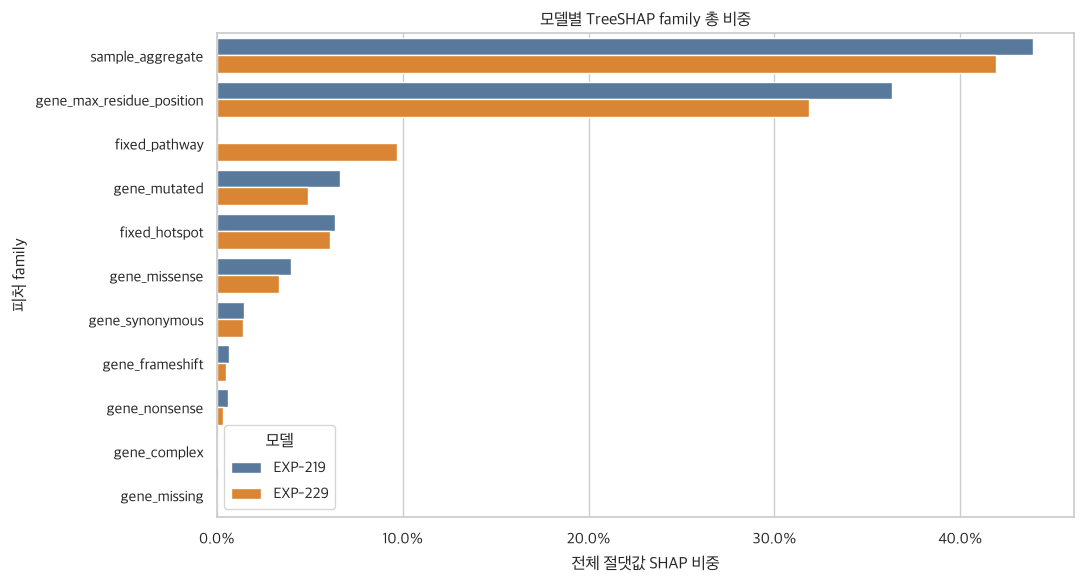

,family,feature_count,total_mean_abs_shap,total_share,mean_per_feature,model
0,sample_aggregate,12,1.385630,0.439152,0.115469,EXP-219
1,gene_max_residue_position,4384,1.146259,0.363288,0.000261,EXP-219
2,gene_mutated,4384,0.209665,0.066450,0.000048,EXP-219
3,fixed_hotspot,35,0.200654,0.063594,0.005733,EXP-219
4,gene_missense,4384,0.125898,0.039901,0.000029,EXP-219
5,gene_synonymous,4384,0.046686,0.014796,0.000011,EXP-219
6,gene_frameshift,4384,0.021050,0.006672,0.000005,EXP-219
7,gene_nonsense,4384,0.019396,0.006147,0.000004,EXP-219
8,gene_complex,4384,0.000000,0.000000,0.000000,EXP-219
9,gene_missing,4384,0.000000,0.000000,0.000000,EXP-219


In [2]:
family_order = (
    family.groupby('family')['total_share'].max().sort_values(ascending=False).index
)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=family, y='family', x='total_share', hue='model',
    order=family_order, palette=COLORS, ax=ax
)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(title='모델별 TreeSHAP family 총 비중', xlabel='전체 절댓값 SHAP 비중', ylabel='피처 family')
ax.legend(title='모델')
plt.tight_layout()
plt.show()
family.sort_values(['model', 'total_share'], ascending=[True, False]).reset_index(drop=True)

## 2. 피처 하나당 평균 기여

`mean_per_feature`는 family 크기를 보정해 한 열이 평균적으로 얼마나 사용됐는지 보여줍니다. 로그 축이므로 0인 family는 그래프에서 제외합니다.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


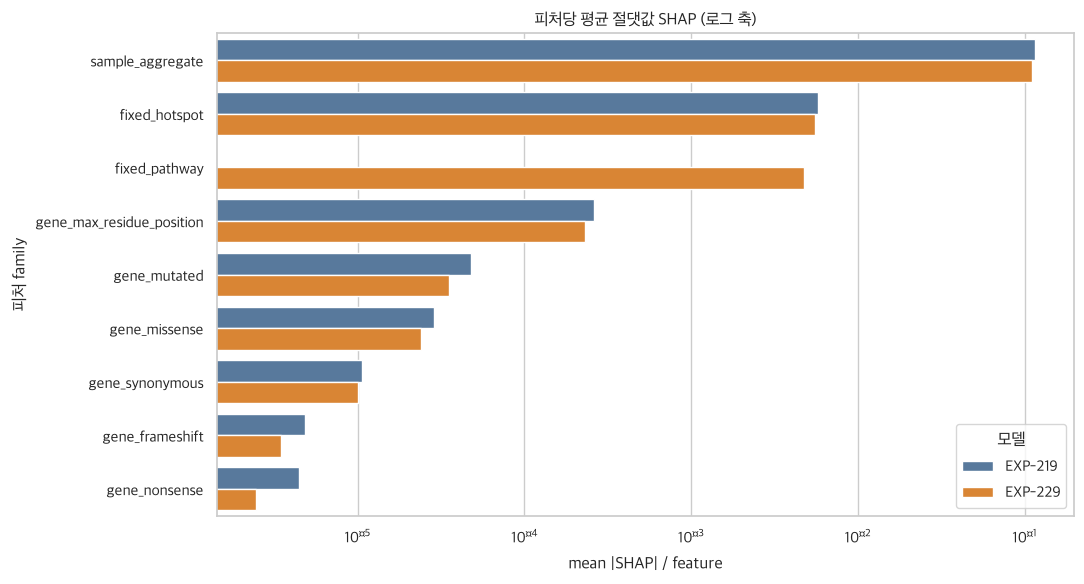

In [3]:
per_feature = family[family['mean_per_feature'] > 0].copy()
order = per_feature.groupby('family')['mean_per_feature'].max().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=per_feature, y='family', x='mean_per_feature', hue='model',
    order=order, palette=COLORS, ax=ax
)
ax.set_xscale('log')
ax.set(title='피처당 평균 절댓값 SHAP (로그 축)', xlabel='mean |SHAP| / feature', ylabel='피처 family')
ax.legend(title='모델')
plt.tight_layout()
plt.show()

## 3. 전역 상위 피처와 두 모델의 유사성

두 모델의 상위 피처 순위 중 합집합을 비교하고, top-k 집합의 교집합 비율을 확인합니다.

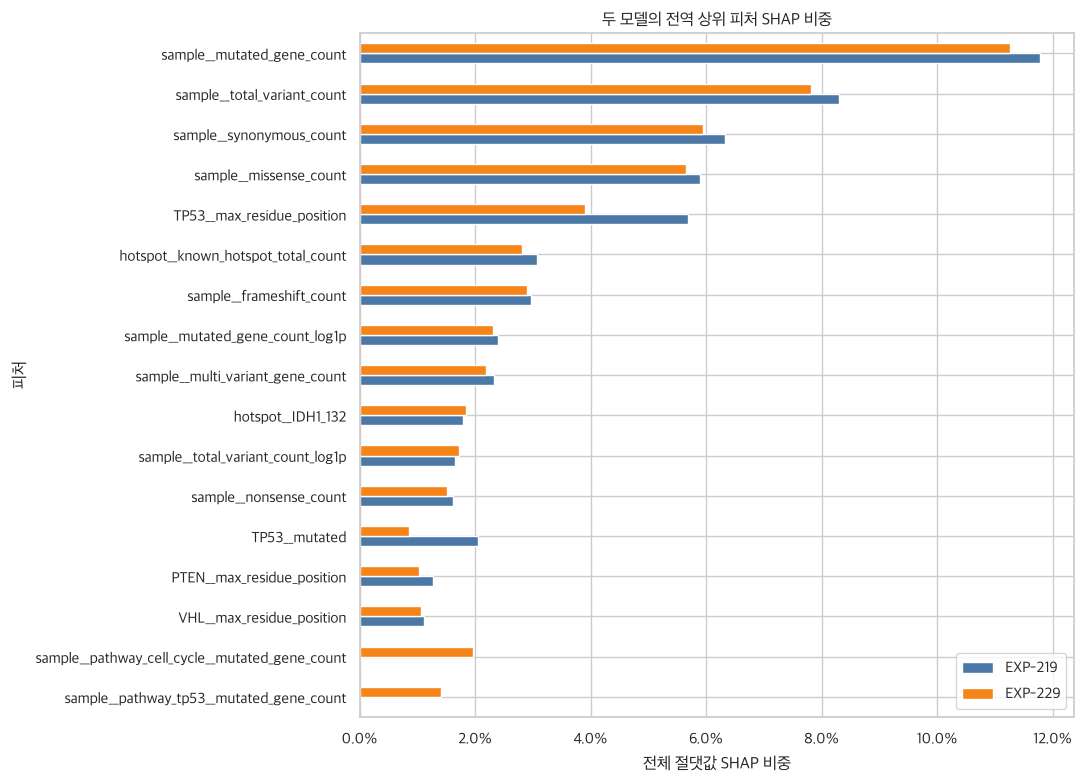

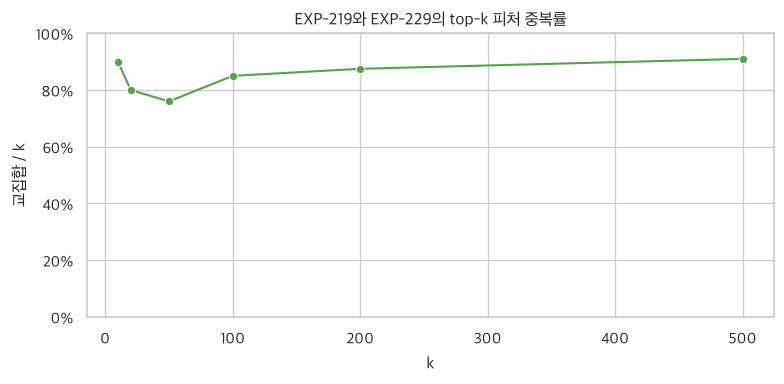

,top_k,intersection,overlap_ratio
0,10,9,0.900
1,20,16,0.800
2,50,38,0.760
3,100,85,0.850
4,200,175,0.875
5,500,455,0.910


In [4]:
top_n = 15
union = sorted(set(global_top['EXP-219'].head(top_n)['feature']) | set(global_top['EXP-229'].head(top_n)['feature']))
compare = pd.concat([
    global_top[model].set_index('feature').reindex(union)[['share']].rename(columns={'share': model})
    for model in MODEL_FILES
], axis=1).fillna(0)
compare['mean'] = compare.mean(axis=1)
compare = compare.sort_values('mean', ascending=True)
fig, ax = plt.subplots(figsize=(11, 8))
compare[['EXP-219', 'EXP-229']].plot.barh(color=COLORS, ax=ax)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(title='두 모델의 전역 상위 피처 SHAP 비중', xlabel='전체 절댓값 SHAP 비중', ylabel='피처')
plt.tight_layout()
plt.show()

ks = [10, 20, 50, 100, 200, 500]
overlap = []
for k in ks:
    left = set(global_top['EXP-219'].head(k)['feature'])
    right = set(global_top['EXP-229'].head(k)['feature'])
    overlap.append({'top_k': k, 'intersection': len(left & right), 'overlap_ratio': len(left & right) / k})
overlap = pd.DataFrame(overlap)
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=overlap, x='top_k', y='overlap_ratio', marker='o', color='#54A24B', ax=ax)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(ylim=(0, 1), title='EXP-219와 EXP-229의 top-k 피처 중복률', xlabel='k', ylabel='교집합 / k')
plt.tight_layout()
plt.show()
overlap

## 4. EXP-229에서 새로 사용된 pathway 피처

EXP-229가 추가한 fixed-pathway family의 전역 피처를 따로 확인합니다.

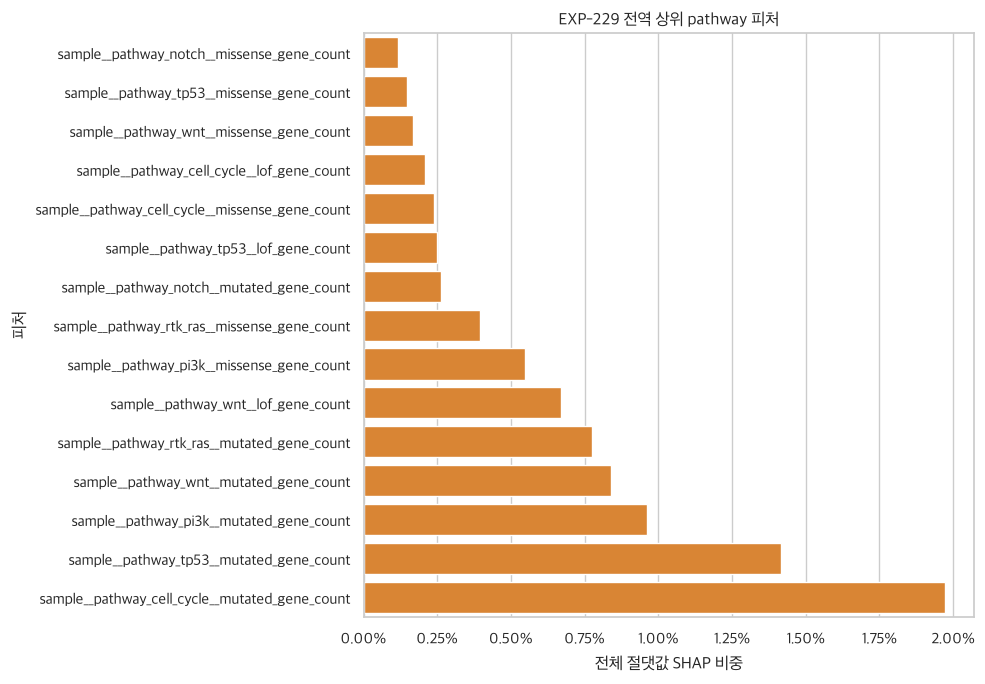

,feature,family,mean_abs_shap,share,rank
9,sample__pathway_cell_cycle__mutated_gene_count,fixed_pathway,0.062238,0.019720,10
13,sample__pathway_tp53__mutated_gene_count,fixed_pathway,0.044717,0.014168,14
17,sample__pathway_pi3k__mutated_gene_count,fixed_pathway,0.030386,0.009628,18
19,sample__pathway_wnt__mutated_gene_count,fixed_pathway,0.026442,0.008378,20
20,sample__pathway_rtk_ras__mutated_gene_count,fixed_pathway,0.024408,0.007734,21
23,sample__pathway_wnt__lof_gene_count,fixed_pathway,0.021156,0.006703,24
26,sample__pathway_pi3k__missense_gene_count,fixed_pathway,0.017261,0.005469,27
31,sample__pathway_rtk_ras__missense_gene_count,fixed_pathway,0.012486,0.003956,32
43,sample__pathway_notch__mutated_gene_count,fixed_pathway,0.008331,0.002640,44
44,sample__pathway_tp53__lof_gene_count,fixed_pathway,0.007884,0.002498,45


In [5]:
pathway_global = global_top['EXP-229'].query("family == 'fixed_pathway'").head(15).sort_values('share')
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=pathway_global, y='feature', x='share', color='#F58518', ax=ax)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(title='EXP-229 전역 상위 pathway 피처', xlabel='전체 절댓값 SHAP 비중', ylabel='피처')
plt.tight_layout()
plt.show()
pathway_global.sort_values('rank')

## 5. 암종별 pathway 사용 패턴

클래스별 top 20에 등장한 pathway 피처만 표시합니다. 0은 실제 SHAP이 0이라는 뜻이 아니라 그 클래스의 top 20 밖이라는 뜻입니다.

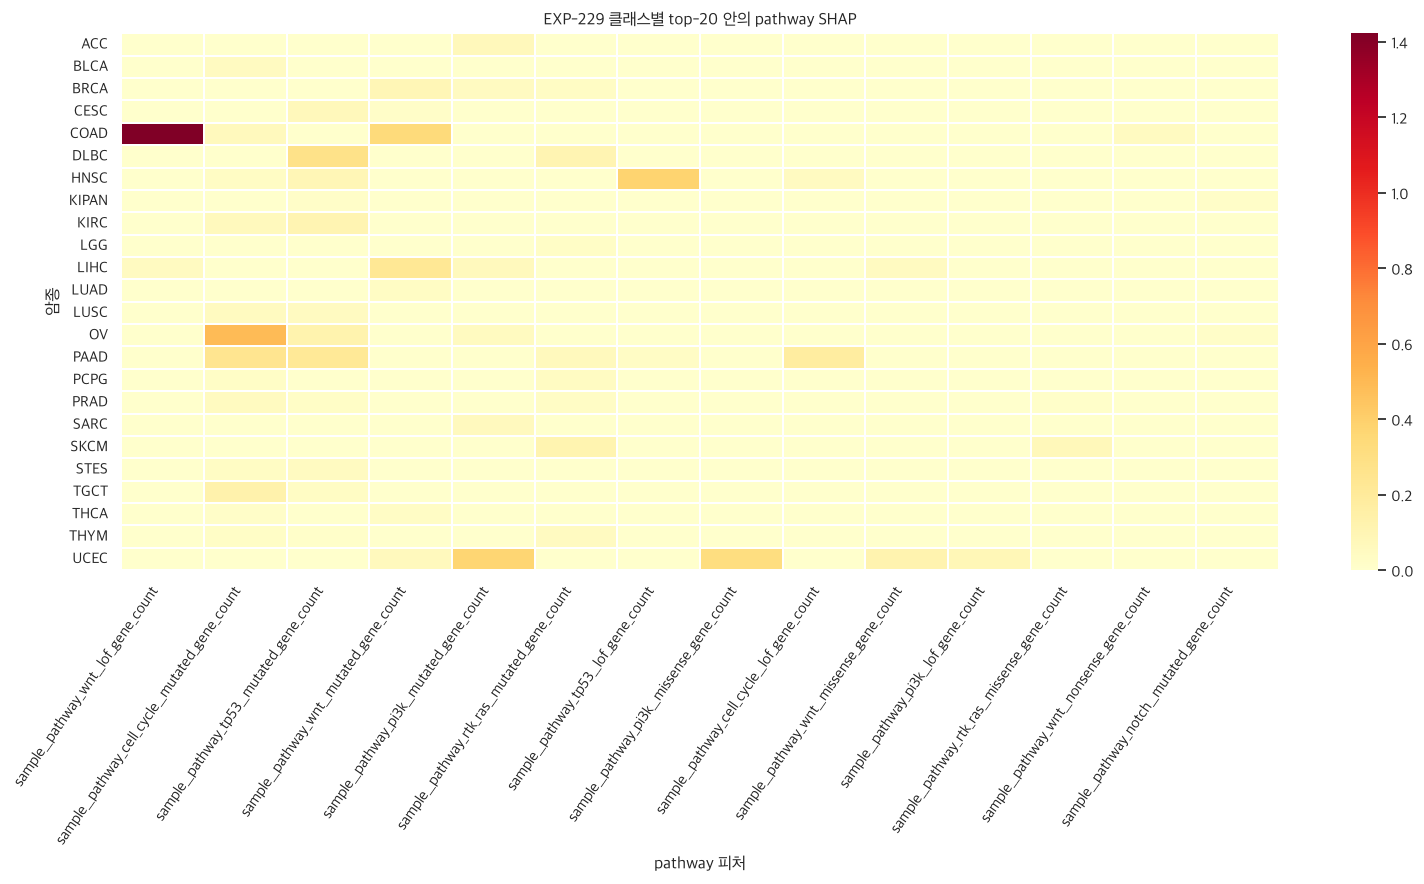

클래스별 top 20에 pathway 피처가 등장한 암종: 24 / 26


In [6]:
class229 = class_top['EXP-229']
class_pathway = class229.query("family == 'fixed_pathway'").copy()
pathway_order = (
    class_pathway.groupby('feature')['mean_abs_true_class_shap'].sum()
    .nlargest(14).index
)
heat = (
    class_pathway[class_pathway['feature'].isin(pathway_order)]
    .pivot(index='class', columns='feature', values='mean_abs_true_class_shap')
    .reindex(columns=pathway_order).fillna(0)
)
fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(heat, cmap='YlOrRd', linewidths=0.25, ax=ax)
ax.set(title='EXP-229 클래스별 top-20 안의 pathway SHAP', xlabel='pathway 피처', ylabel='암종')
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.show()
print(f"클래스별 top 20에 pathway 피처가 등장한 암종: {class_pathway['class'].nunique()} / 26")

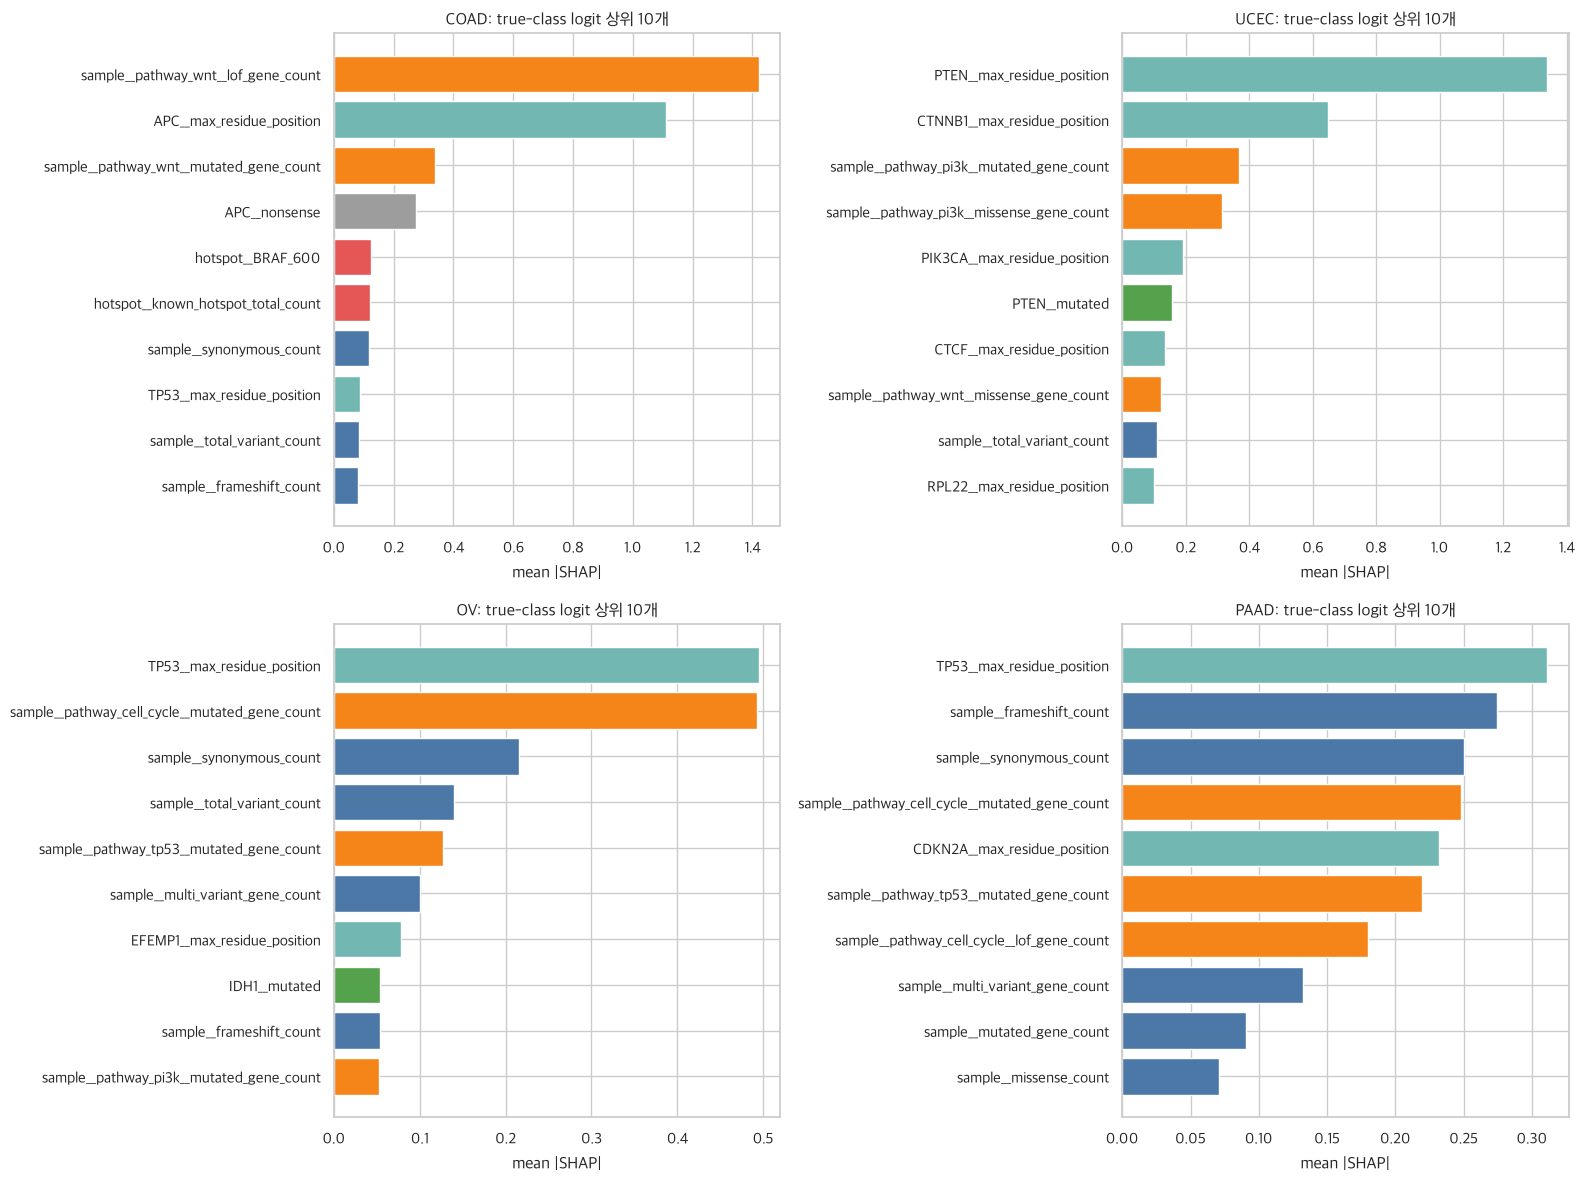

In [7]:
selected_classes = ['COAD', 'UCEC', 'OV', 'PAAD']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
family_palette = {
    'sample_aggregate': '#4C78A8', 'gene_max_residue_position': '#72B7B2',
    'fixed_pathway': '#F58518', 'fixed_hotspot': '#E45756',
    'gene_mutated': '#54A24B', 'gene_missense': '#B279A2',
}
for cancer, ax in zip(selected_classes, axes.flat):
    frame = class229.query('`class` == @cancer').head(10).sort_values('mean_abs_true_class_shap')
    colors = [family_palette.get(family, '#9D9D9D') for family in frame['family']]
    ax.barh(frame['feature'], frame['mean_abs_true_class_shap'], color=colors)
    ax.set_title(f'{cancer}: true-class logit 상위 10개')
    ax.set_xlabel('mean |SHAP|')
plt.tight_layout()
plt.show()

## 해석 요약

1. 두 모델 모두 sample aggregate와 residue-position 신호에 크게 의존합니다.
2. EXP-229는 기존 핵심 신호를 유지하면서 fixed pathway가 전체 절댓값 SHAP의 약 9.68%를 담당합니다.
3. 상위 10개 중 9개, 상위 20개 중 16개, 상위 100개 중 85개가 겹쳐 두 모델의 규칙은 상당히 유사합니다.
4. pathway 피처는 26개 클래스 중 24개의 클래스별 top 20에 등장합니다.
5. 이는 사후 설명이며 생물학적 인과나 독립 검증을 뜻하지 않습니다. 상관된 피처 사이에서는 SHAP이 분산될 수 있고 클래스당 최대 15행만 표본화했습니다.